In [1]:
from pymargo.core import Engine
import pyyokan_common as yokan
from pyyokan_client import Client
from pyyokan_server import Provider

import json
import ctypes
import struct
import blosc2
import numpy as np
import numpy as np
from pathlib import Path
import sys

In [2]:
sys.path.append('/projects/insituperf/seer_o/venv-seer/lib/python3.11/site-packages')

In [3]:
sys.path.append('/projects/insituperf/SZ3/tools/pysz/')
from pysz import SZ

In [4]:
import pyvista as pv

In [5]:
def list_all_keys(db):
    num_keys = db.count()
    
    max_length = 1024
    prefix = ''
    out_keys = []
    for i in range(0, num_keys):
      out_keys.append( bytearray(max_length+len(prefix)+1) )
    
    from_key = ''
    ksizes = db.list_keys(keys=out_keys, from_key=from_key, filter=prefix)
    
    keys = []
    for i in range(len(ksizes)):
        key_size = ksizes[i]
        
        k = out_keys[i]
        key = (k[:key_size]).decode('ascii')
        keys.append(key)
        
    return keys

In [24]:
def list_keys(db, simid):
    all_keys = list_all_keys(db)

    x = []
    for k in all_keys:
        parts = k.split('/')
        if parts[0] == '_' + str(simid):
            x.append(k)

    return x

In [6]:
def list_fields(db, simid):
    
    all_keys = list_all_keys(db)
    
    x = []
    for k in all_keys:
        parts = k.split('/')
        if parts[0] == '_' + str(simid):
            if len(parts) == 5:
                name = parts[len(parts)-2]
                x.append(name)
        
    return list(set(x))

In [7]:
def list_attributes(db, simid):
    all_keys = list_all_keys(db)

    x = []
    for k in all_keys:
        parts = k.split('/')
        if parts[0] == '_' + str(simid):
            if len(parts) == 5:
                name = parts[len(parts)-1]
                x.append(name)

    return list(set(x))

In [8]:
def get_value(db, key):
    ''' Get data from the server for that key '''

    # length of the value associated with the key
    l = db.length(key)

    out_val = bytearray(l)          # create buffer
    db.get(key=key, value=out_val)  # get the data
    v = out_val.decode("ascii")     # convert to ascii
    return v

In [9]:
def get_data(db, key):
    ''' Get data from the server for that key '''

    # length of the value associated with the key
    l = db.length(key)

    out_val = bytearray(l)          # create buffer
    db.get(key=key, value=out_val)  # get the data
    return out_val

In [10]:
def get_decompDataBLOSC(db, key, num_elems):
        x = []
        
        val = get_data(db, key)
        a_bytesobj2 = blosc2.decompress(val)
        
        bf = str(num_elems) + 'f'
        x = struct.unpack(bf, a_bytesobj2)

        return x

In [11]:
def get_decompDataSZ3(db, key, num_elems):
        data = get_data(db, key)
        np_array = np.frombuffer(data, dtype=np.uint8)
        
        lib_extention = {
            "darwin": "libSZ3c.dylib",
            "windows": "SZ3c.dll",
        }.get(sys.platform, "libSZ3c.so")

        sz = SZ("/projects/insituperf/SZ3/install/lib64/{}".format(lib_extention))
        
        data_dec = sz.decompress(np_array, (num_elems,1,1), np.float32)


        return data_dec

In [12]:
def isTsReady(db, ts, simid):
    key = '_' + simid + '/' + ts +'/status'
    return get_value(db, key)

In [13]:
def getNumRanks(db, simid):
    key = '_' + simid + '/num_ranks'
    return get_value(db, key)

In [14]:
#f = open('/projects/insituperf/seer_o/test_app/mochi-yokan-config.json')
f = open('/vast/projects/exasky/pascal/HACC/trunk/mochi-yokan-config.json')

In [15]:
json_data = json.load(f)
json_data

{'sim-id': '56789',
 'libraries': {'yokan': '/vast/home/pascalgrosset/spack/opt/spack/linux-rhel8-haswell/gcc-9.4.0/mochi-yokan-0.4.2-hiu7yh7om6nmyc2ahuknpdsov5k64zcj/lib/libyokan-bedrock-module.so'},
 'providers': [{'name': 'yokan_provider',
   'provider_id': 124,
   'type': 'yokan',
   'pool': '__primary__',
   'config': {'database': {'type': 'map'}}}],
 'data': [{'name': 'phi', 'compressor': 'SZ3', 'mode': 'psnr', 'value': 45},
  {'name': 'x', 'compressor': 'SZ3', 'mode': 'abs', 'value': 0.2},
  {'name': 'y', 'compressor': 'SZ3', 'mode': 'abs', 'value': 0.2},
  {'name': 'z', 'compressor': 'SZ3', 'mode': 'abs', 'value': 0.2}],
 'databases': [{'address': '192.168.81.72:45705',
   'protocol': 'ofi+tcp',
   'provider_id': 124}]}

In [16]:
server_addr1 = "ofi+tcp://192.168.81.72:45705"
provider_id = 124
protocol = 'ofi+tcp'

In [17]:
engine1 = Engine(protocol)
mid1 = engine1.get_internal_mid()
addr1 = engine1.lookup(server_addr1)
hg_addr1 = addr1.get_internal_hg_addr()
provider1 = Provider(mid=mid1, provider_id=provider_id, config='{"database":{"type":"map"}}')
client1 = Client(mid=mid1)
db1 = client1.make_database_handle(address=hg_addr1, provider_id=provider_id)

In [ ]:
server_addr2 = "ofi+tcp://192.168.81.78:45745"
provider_id = 124
protocol = 'ofi+tcp'

In [ ]:
engine2 = Engine(protocol)
mid2 = engine2.get_internal_mid()
addr2 = engine2.lookup(server_addr2)
hg_addr2 = addr2.get_internal_hg_addr()
provider2 = Provider(mid=mid2, provider_id=provider_id, config='{"database":{"type":"map"}}')
client2 = Client(mid=mid2)
db2 = client2.make_database_handle(address=hg_addr2, provider_id=provider_id)

In [18]:
dbs = []

In [19]:
dbs.append(db1)


In [ ]:
dbs.append(db2)

In [ ]:
ts = '0'

In [ ]:
simid = '07730'

In [20]:
keys = list_all_keys(dbs[0])
keys

['_07730/0/0/pressure_3/compressed_size',
 '_07730/0/0/pressure_3/dbIndex',
 '_07730/0/0/pressure_3/num_elems',
 '_07730/0/0/pressure_3/type',
 '_07730/0/0/pressure_3/value',
 '_07730/0/0/temperature_3/compressed_size',
 '_07730/0/0/temperature_3/dbIndex',
 '_07730/0/0/temperature_3/num_elems',
 '_07730/0/0/temperature_3/type',
 '_07730/0/0/temperature_3/value',
 '_07730/0/1/pressure_3/compressed_size',
 '_07730/0/1/pressure_3/dbIndex',
 '_07730/0/1/pressure_3/num_elems',
 '_07730/0/1/pressure_3/type',
 '_07730/0/1/pressure_3/value',
 '_07730/0/1/temperature_3/compressed_size',
 '_07730/0/1/temperature_3/dbIndex',
 '_07730/0/1/temperature_3/num_elems',
 '_07730/0/1/temperature_3/type',
 '_07730/0/1/temperature_3/value',
 '_07730/0/status',
 '_07730/1/0/pressure_3/compressed_size',
 '_07730/1/0/pressure_3/dbIndex',
 '_07730/1/0/pressure_3/num_elems',
 '_07730/1/0/pressure_3/type',
 '_07730/1/0/pressure_3/value',
 '_07730/1/0/temperature_3/compressed_size',
 '_07730/1/0/temperature_3/dbI

In [25]:
list_keys(dbs[0],'56789')

['_56789/0/0/phi/compressed_size',
 '_56789/0/0/phi/num_elems',
 '_56789/0/0/phi/type',
 '_56789/0/0/phi/value',
 '_56789/0/0/x/compressed_size',
 '_56789/0/0/x/num_elems',
 '_56789/0/0/x/type',
 '_56789/0/0/x/value',
 '_56789/0/0/y/compressed_size',
 '_56789/0/0/y/num_elems',
 '_56789/0/0/y/type',
 '_56789/0/0/y/value',
 '_56789/0/0/z/compressed_size',
 '_56789/0/0/z/num_elems',
 '_56789/0/0/z/type',
 '_56789/0/0/z/value',
 '_56789/0/1/phi/compressed_size',
 '_56789/0/1/phi/num_elems',
 '_56789/0/1/phi/type',
 '_56789/0/1/phi/value',
 '_56789/0/1/x/compressed_size',
 '_56789/0/1/x/num_elems',
 '_56789/0/1/x/type',
 '_56789/0/1/x/value',
 '_56789/0/1/y/compressed_size',
 '_56789/0/1/y/num_elems',
 '_56789/0/1/y/type',
 '_56789/0/1/y/value',
 '_56789/0/1/z/compressed_size',
 '_56789/0/1/z/num_elems',
 '_56789/0/1/z/type',
 '_56789/0/1/z/value',
 '_56789/0/2/phi/compressed_size',
 '_56789/0/2/phi/num_elems',
 '_56789/0/2/phi/type',
 '_56789/0/2/phi/value',
 '_56789/0/2/x/compressed_size'

In [ ]:
fields = list_fields(dbs[0], simid)
fields

In [ ]:
attributes = list_attributes(dbs[0], simid)
attributes

In [ ]:
isTsReady(dbs[0], '1', simid)

In [ ]:
get_value(dbs[0], '_07730/0/status',)

In [ ]:
getNumRanks(dbs[0], simid)

In [ ]:
get_value(dbs[0], "_07720/0/1/pressure_3/dbIndex")

In [ ]:
get_value(dbs[0], "_07720/1/1/pressure_3/dbIndex")

In [ ]:
nE = get_value(dbs[0],"_07720/0/1/pressure_3/num_elems")
nE

In [ ]:
get_value(dbs[0],"_0777/4/1/pressure_3/num_elems")

In [ ]:
pressure_3 = get_decompDataBLOSC(dbs[0], "_0777/4/1/pressure_3/value", 100)
pressure_3

In [ ]:
pressure_3 = get_decompDataBLOSC(dbs[1], "_07720/1/1/pressure_3/value", 100)
pressure_3

In [ ]:
len(com_x)

In [57]:
get_value(db, "_56789/499/0/x/num_elems")

'3080753'

In [58]:
val_x = get_decompDataSZ3(db, "_56789/499/0/x/value", 3080753)
vals_x = val_x.flatten()

In [59]:
val_y = get_decompDataSZ3(db, "_56789/499/0/y/value", 3080753)
vals_y = val_y.flatten()

In [60]:
val_z = get_decompDataSZ3(db, "_56789/499/0/z/value", 3080753)
vals_z = val_z.flatten()

In [61]:
xxx= np.stack([vals_x,vals_y,vals_z], axis=1)

Widget(value='<iframe src="darwin-fe.lanl.gov:887934915/index.html?ui=P_0x149d9ca63910_44&reconnect=auto" clas…

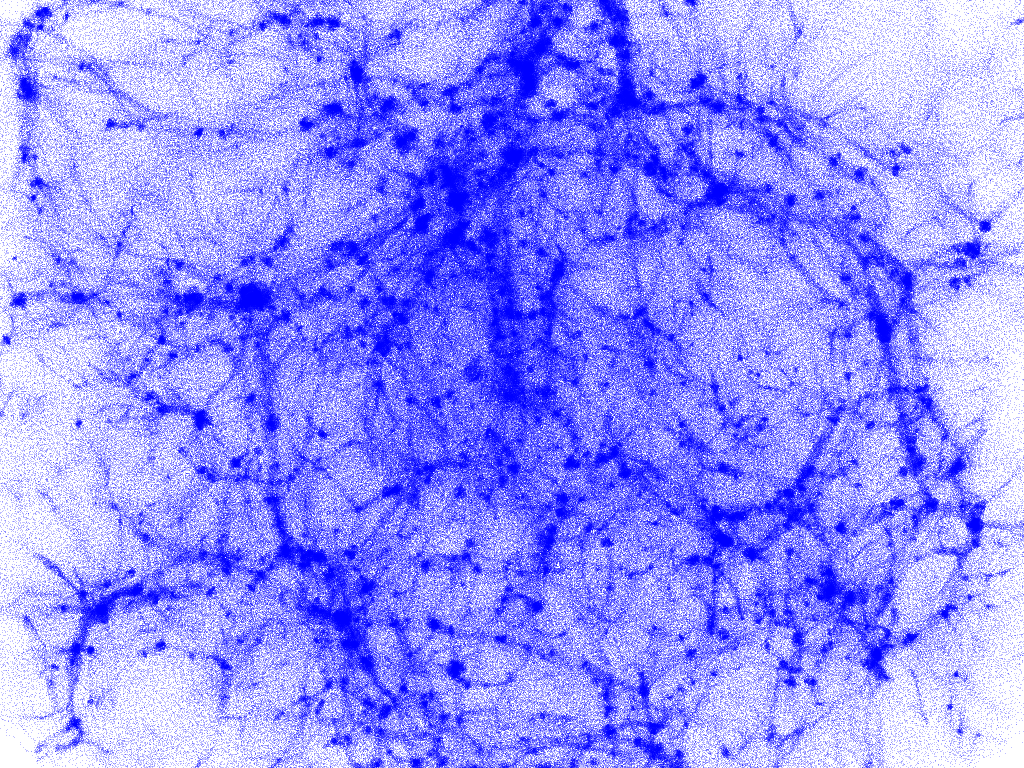

In [55]:
import pyvista as pv
from pyvista import examples
from pyvista.trame.jupyter import elegantly_launch, launch_server

pv.global_theme.trame.server_proxy_enabled = True
pv.global_theme.trame.server_proxy_prefix = 'darwin-fe.lanl.gov:8879' # white screen

points = xxx
point_cloud = pv.PolyData(points)
point_cloud.plot(jupyter_backend='trame', eye_dome_lighting=True)
point_cloud.point_size = 0.01
point_cloud.opacity = 0.1

plotter = pv.Plotter(notebook=True)
plotter.add_mesh(point_cloud,opacity=0.25,point_size=1.0,color='#0000ff')
plotter.camera.zoom(4.0)
plotter.show(jupyter_backend='static') #works screen

In [ ]:
np.savetxt("/projects/insituperf/seer_o/3d_array.csv", xxx, delimiter=",")

In [ ]:
np.save('/projects/insituperf/seer_o/my_array.npy', xxx)

In [ ]:
import pyvista as pv

In [ ]:
%pip list

In [ ]:
!{sys.executable} -m pip install 'pyvista[jupyter]>=0.38.1'